In [1]:
# %%
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
# If running as a non-interactive .py job on HPC, keep this.
# If running in Jupyter and you want inline plots, you can comment this out.
# matplotlib.use("Agg")

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rcParams

import torch
import scvi
import cell2location

from scipy import sparse

rcParams["pdf.fonttype"] = 42  # enables correct plotting of text for PDFs

## Setting up for CPU environment

In [2]:
import os
import torch
import scvi

n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 8))
n_workers = max(1, n_cpus - 1)

torch.set_num_threads(n_cpus)
scvi.settings.num_threads = n_cpus
scvi.settings.dl_num_workers = n_workers

print(f"Using {n_cpus} CPU threads and {n_workers} dataloader workers")

Using 16 CPU threads and 15 dataloader workers


In [7]:
from pathlib import Path
import os
import cell2location
import scvi
import torch

print("cell2location:", getattr(cell2location, "__version__", "unknown"))
print("scvi:", scvi.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

print("\nModel directory:")
print(run_name)

print("\nFiles in model directory:")
for p in Path(run_name).iterdir():
    print(p.name, p.stat().st_size / 1e6, "MB")

cell2location: 0.1.5
scvi: 1.4.1
torch: 2.5.1
CUDA available: False

Model directory:
/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/c2l_run_output/c2l_lvl2_epochs_200_Ncells1_decalpha_100

Files in model directory:
model.pt 1226.612839 MB


# Data

## Variables

In [3]:
N_cells_loc  = 1
dec_alpha    = 100
gpus_dev     = 4


epoch_num    = 200 # First run was about 200 epochs. Let's try 500 epochs to see if it improves the results.
batch_num    = 8192 #4096, 8192, 16384, 32768
export_num   = 250 #500 reduced for faster rnu # 1k was too much for the GPU memory

In [4]:
# Selected level of annotation for training the model.
level = 1
levels = ["cell_type_lvl1", "cell_type_lvl2", "cell_type_lvl3"]

level_short = {
    "cell_type_lvl1": "lvl1",
    "cell_type_lvl2": "lvl2",
    "cell_type_lvl3": "lvl3",
}

current_level = levels[level]
lvl_name_short =level_short[current_level]

## Locations

In [5]:
# Project folder
# proj_folder   = Path("/Users/janzules/Roselab/Spatial/CAR_T/")
proj_folder    = Path("/coh_labs/yunroseli/Jona/CAR-T/")
input_folder    = proj_folder / "data/zarr/fullDataset/annotating_references"
c2l_folder     = input_folder / "c2l_run_output"

# Files for training and mapping
# input_folder   = c2l_folder / "C2L_inputs"

# figures_folder = proj_folder / "figures/cell2location/mapping"


# ref_loc        = input_folder / "ref_adata_c2l_model.h5ad"
spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# Output location - Not sure what these are for
ref_run_name   = c2l_folder / f"reference_signatures_{lvl_name_short}"
run_name       = c2l_folder / f"c2l_{lvl_name_short}_epochs_{epoch_num}_Ncells{N_cells_loc}_decalpha_{dec_alpha}"

# After training
trained_sc_data_file = input_folder / f"sc_with_signatures_{lvl_name_short}.h5ad"
predicted_cells_file = input_folder / f"predicted_cells_{lvl_name_short}_epochs_{epoch_num}_Ncells{N_cells_loc}_decalpha_{dec_alpha}.h5ad"

In [6]:
# Load data
adata_vis = sc.read_h5ad(spatial_loc)
adata_ref = sc.read_h5ad(trained_sc_data_file)

## Loading sdata parameters

In [8]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B,CD4_T,CD8_T,Cancer_cell,Classical_Mono
gene_id,,,,,
ENSMUSG00000051951,0.029603,0.017300,0.011325,0.010806,0.000611
ENSMUSG00000025902,0.022129,0.012658,0.001919,0.000348,0.000076
ENSMUSG00000025903,0.168787,0.388103,0.279053,0.086015,0.251908
ENSMUSG00000033813,0.215083,0.738445,0.530219,0.589549,0.514592
ENSMUSG00000002459,0.574192,0.309674,0.020432,0.005635,0.000237


## Preparing data and model

In [9]:
# find shared genes and subset both anndata and reference signatures
# MT was removed from vis data, and the infe_aver selected the most relevant genes for annotating
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)

In [10]:
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
# cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="TMA")

In [11]:
print(f"The amount of genes in visium data: {adata_vis.shape[1]}")
print(f"The amount of genes in reference signatures: {inf_aver.shape[0]}")

The amount of genes in visium data: 12176
The amount of genes in reference signatures: 12176


## Exporting

In [13]:
print(f"\nLoading saved cell2location model from:\n{run_name}")

mod = cell2location.models.Cell2location.load(
    f"{run_name}",
    adata_vis
)

print("Saved model loaded successfully.")
mod.view_anndata_setup()



Loading saved cell2location model from:
/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/c2l_run_output/c2l_lvl2_epochs_200_Ncells1_decalpha_100
INFO     File                                                                                                      
         /coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/annotating_references/c2l_run_output/c2l_lvl2_epochs_
         200_Ncells1_decalpha_100/model.pt already downloaded                                                      


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your 

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

: 

: 

: 

In [ ]:
adata_vis = mod.export_posterior(
    adata_vis, 
    sample_kwargs={'num_samples': export_num, 'batch_size': batch_num}, # Originally 1000,
)

In [ ]:
adata_vis.write(predicted_cells_file)

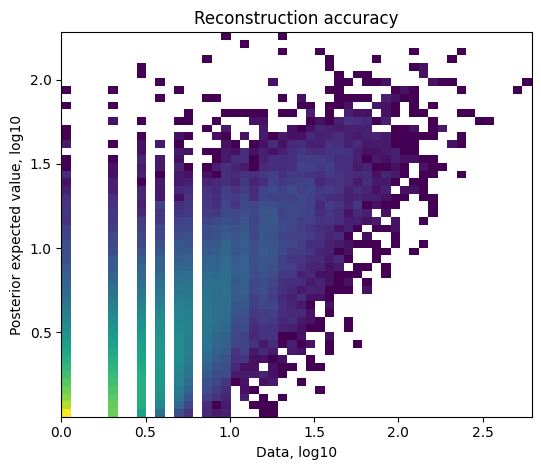

In [ ]:
mod.plot_QC()